# EDA – Macroeconomic features and multicollinearity – Member 4


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Bank Marketing dataset
DATA_PATH = "../data/raw/bank-additional-full.csv"

df = pd.read_csv(DATA_PATH, sep=";")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
df.head()

Dataset loaded successfully!
Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Macroeconomic Feature Overview

The dataset contains five macroeconomic indicators recorded at the time of each contact. This section examines their distributions and relationships with the term-deposit subscription target.

In [3]:
macro_features = [
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

df[macro_features].describe().T

,count,mean,std,min,25%,50%,75%,max
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


## Distribution of Macroeconomic Features

Histograms are used to examine the range, concentration, and distribution shape of each macroeconomic indicator.

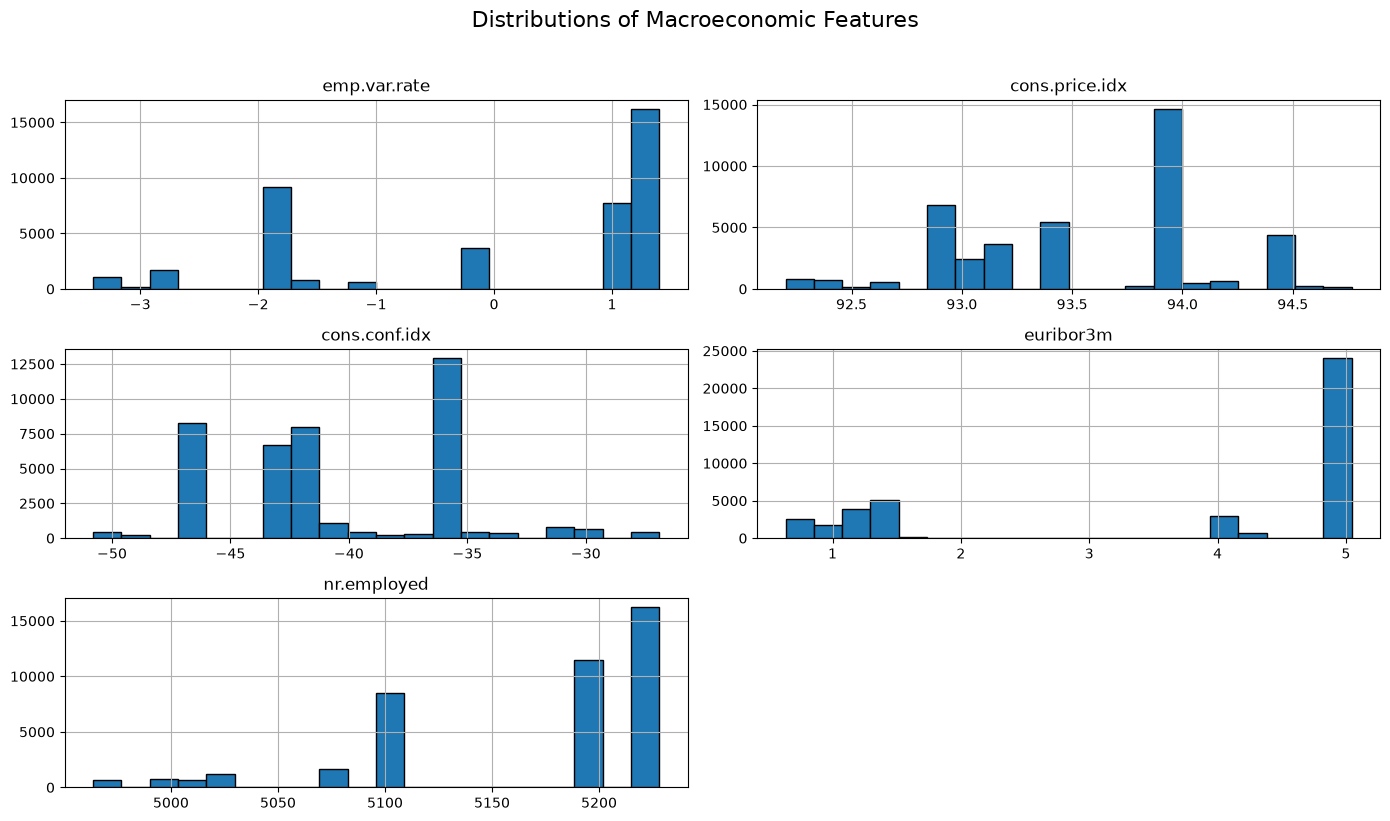

In [4]:
df[macro_features].hist(
    figsize=(14, 8),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distributions of Macroeconomic Features",
    fontsize=16,
    y=1.02
)
plt.tight_layout()
plt.show()

## Correlation and Multicollinearity Analysis

A correlation matrix is used to identify strong relationships among the macroeconomic predictors. Very high correlations may indicate multicollinearity, where multiple features provide similar information.

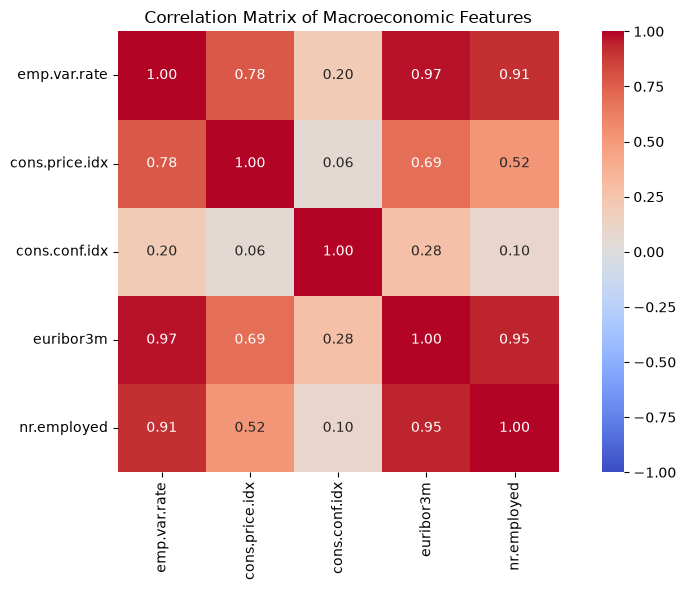

In [5]:
macro_corr = df[macro_features].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    macro_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Matrix of Macroeconomic Features")
plt.tight_layout()
plt.show()

### Key Finding

Strong positive correlations were found between `emp.var.rate`, `euribor3m`, and `nr.employed`. The highest correlation is between `emp.var.rate` and `euribor3m` (0.97), followed by `euribor3m` and `nr.employed` (0.95), and `emp.var.rate` and `nr.employed` (0.91). These values indicate substantial multicollinearity. Keeping all three variables may add redundant information and may make coefficient-based models less stable. Feature selection or regularisation should therefore be considered inside the training pipeline.

,correlation_with_target
nr.employed,-0.354678
euribor3m,-0.307771
emp.var.rate,-0.298334
cons.price.idx,-0.136211
cons.conf.idx,0.054878


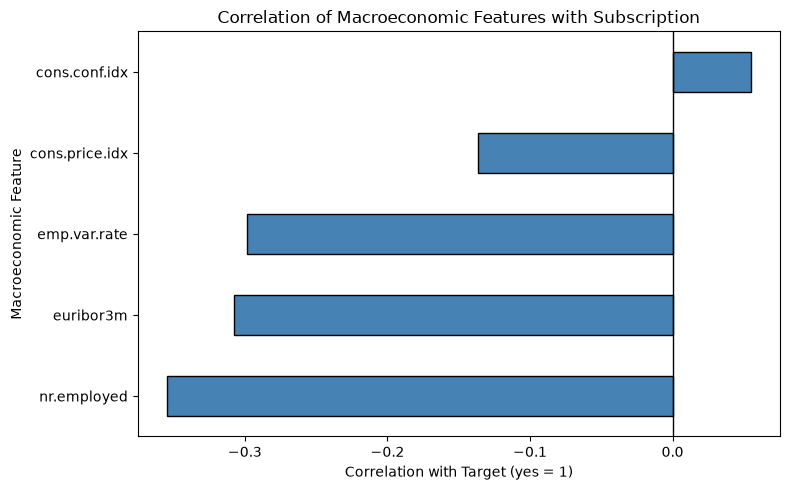

In [6]:
target_analysis = df[macro_features].copy()
target_analysis["subscribed"] = (df["y"] == "yes").astype(int)

target_correlations = (
    target_analysis.corr()["subscribed"]
    .drop("subscribed")
    .sort_values()
)

display(target_correlations.to_frame("correlation_with_target"))

plt.figure(figsize=(8, 5))
target_correlations.plot(
    kind="barh",
    color="steelblue",
    edgecolor="black"
)

plt.title("Correlation of Macroeconomic Features with Subscription")
plt.xlabel("Correlation with Target (yes = 1)")
plt.ylabel("Macroeconomic Feature")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

### Relationship with Subscription

`nr.employed` has the strongest correlation with subscription (`r = -0.355`), followed by `euribor3m` (`r = -0.308`) and `emp.var.rate` (`r = -0.298`). Their negative correlations indicate that subscriptions were more common during periods with lower employment levels, interest rates, and employment-variation rates in this dataset. `cons.conf.idx` has only a very weak positive relationship (`r = 0.055`). These correlations describe associations and should not be interpreted as direct causal effects.

In [7]:
upper_triangle = macro_corr.where(
    np.triu(np.ones(macro_corr.shape), k=1).astype(bool)
)

high_correlation_pairs = (
    upper_triangle.stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

high_correlation_pairs = high_correlation_pairs[
    high_correlation_pairs["correlation"].abs() >= 0.80
].sort_values("correlation", ascending=False)

high_correlation_pairs

,feature_1,feature_2,correlation
3,emp.var.rate,euribor3m,0.972245
19,euribor3m,nr.employed,0.945154
4,emp.var.rate,nr.employed,0.906970


## Scaling and Feature Selection

As an exploratory preprocessing demonstration, StandardScaler is applied to the five macroeconomic features to examine standardized values.

SelectKBest with mutual information is also used to demonstrate feature ranking and selection based on the subscription target.

These steps are demonstrated on the full dataset for exploratory analysis only. In the final modelling stage, preprocessing and feature selection should be fitted only on the training data or within cross-validation to prevent data leakage.

In [8]:
from sklearn.preprocessing import StandardScaler

# Macroeconomic features used for scaling
X_macro = df[macro_features].copy()

scaler = StandardScaler()
X_macro_scaled = scaler.fit_transform(X_macro)

scaled_macro_df = pd.DataFrame(
    X_macro_scaled,
    columns=macro_features
)

print("Mean after scaling:")
display(scaled_macro_df.mean().round(3).to_frame("mean"))

print("Standard deviation after scaling:")
display(scaled_macro_df.std(ddof=0).round(3).to_frame("std"))

Mean after scaling:


,mean
emp.var.rate,-0.0
cons.price.idx,-0.0
cons.conf.idx,-0.0
euribor3m,-0.0
nr.employed,0.0


Standard deviation after scaling:


,std
emp.var.rate,1.0
cons.price.idx,1.0
cons.conf.idx,1.0
euribor3m,1.0
nr.employed,1.0


In [9]:
from functools import partial
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Convert the target variable to binary
y_binary = (df["y"] == "yes").astype(int)

# Select the top 3 macroeconomic features
selector = SelectKBest(
    score_func=partial(mutual_info_classif, random_state=42),
    k=3
)

selector.fit(X_macro, y_binary)

# Create a table showing feature importance and selection
feature_scores = pd.DataFrame({
    "Feature": macro_features,
    "Mutual Information Score": selector.scores_,
    "Selected": selector.get_support()
}).sort_values(
    "Mutual Information Score",
    ascending=False
)

display(feature_scores)

selected_features = feature_scores[
    feature_scores["Selected"]
]["Feature"].tolist()

print("Selected features:", selected_features)

,Feature,Mutual Information Score,Selected
3,euribor3m,0.073895,True
2,cons.conf.idx,0.069758,True
1,cons.price.idx,0.069182,True
4,nr.employed,0.064522,False
0,emp.var.rate,0.053534,False


Selected features: ['euribor3m', 'cons.conf.idx', 'cons.price.idx']


### Feature Selection Result

SelectKBest with mutual information was used to rank the five macroeconomic features according to their relationship with the subscription target. For this demonstration, the top three features were selected.

The selected features were **euribor3m**, **cons.conf.idx**, and **cons.price.idx**. This shows that feature selection can reduce the number of predictors while retaining informative variables.

The final decision on whether feature selection improves predictive performance will be evaluated during model validation using cross-validation.

## Conclusion and Preprocessing Recommendations

The five macroeconomic variables contain useful information about term-deposit subscription behaviour. `nr.employed`, `euribor3m`, and `emp.var.rate` show the strongest relationships with the target. However, these three predictors are also highly correlated with each other, creating a multicollinearity risk.

The following preprocessing decisions are recommended:

1. Scale numerical features for scale-sensitive models such as Logistic Regression and SVM.
2. Compare models with and without highly correlated macroeconomic features.
3. Use feature selection or regularisation to reduce redundant information.
4. Fit scaling and feature-selection methods only on the training folds through a pipeline to prevent data leakage.
5. Retain all macroeconomic variables initially for tree-based models, because these models are less affected by multicollinearity.
6. Interpret the results carefully because the macroeconomic variables change over time and their correlations do not prove causation.

This analysis provides evidence for the shared preprocessing pipeline and the later feature-selection experiment.